In [1]:
!pip install xgboost
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import json

# Фиксируем случайное состояние для воспроизводимости
np.random.seed(42)


In [4]:
# Загрузка данных из CSV файла (замените 'radon_data.csv' на путь к вашему файлу)
df = pd.read_csv('data.csv', sep=';', decimal=',', parse_dates=['Datetime'], encoding='cp1251')

# Переименуем колонки для удобства (если в данных присутствуют дополнительные описания)
df.columns = ['Datetime', 'Radon', 'Temperature', 'Pressure']

# Убедимся, что данные отсортированы по времени
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# Выведем первые строки для ознакомления с данными
print("Количество записей:", len(df))
print(df.head(5))


Количество записей: 8762
           Datetime    Radon  Temperature    Pressure
0   01.01.2021 0:00  30849.0     1.970866  994.455951
1  01.01.2021 10:00  29436.0     1.949401  996.318096
2  01.01.2021 11:00  25934.0     1.927937  995.993886
3  01.01.2021 12:00  25877.0     1.906476  996.505640
4  01.01.2021 13:00  20905.0     1.901936  996.633681


In [5]:
# Проверим наличие пропусков в данных
print("Пропущенных значений до обработки:")
print(df.isna().sum())

# Приводим колонку Datetime к типу datetime, учитывая формат с днем первым (например, '13.01.2021 0:00')
if not np.issubdtype(df['Datetime'].dtype, np.datetime64):
    df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True, errors='raise')

# Сохраняем флаг, была ли Datetime колонка индексом
reset_index_later = not isinstance(df.index, pd.DatetimeIndex)

# Устанавливаем временную метку как индекс для интерполяции по времени
if reset_index_later:
    df.set_index('Datetime', inplace=True)

# Заполнение пропусков: используем линейную интерполяцию по времени
cols_to_interp = ['Radon', 'Temperature', 'Pressure']
df[cols_to_interp] = df[cols_to_interp].interpolate(method='time')

# Если пропуски остались в начале/конце, заполним их ближайшими известными значениями
df[cols_to_interp] = df[cols_to_interp].fillna(method='bfill').fillna(method='ffill')

# При необходимости возвращаем исходный индекс
if reset_index_later:
    df.reset_index(inplace=True)

# Повторно проверим пропуски
print("Пропущенных значений после обработки:")
print(df.isna().sum())

# Обработка выбросов: ограничение значений на основе метода межквартильного размаха (IQR)
for col in cols_to_interp:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Ограничиваем значения колонки col интервалом [lower_bound, upper_bound]
    df[col] = df[col].clip(lower_bound, upper_bound)

# Данные после обработки выбросов (выведем базовую статистику)
print(df[cols_to_interp].describe().loc[['min','max']])


Пропущенных значений до обработки:
Datetime        0
Radon           9
Temperature    55
Pressure        0
dtype: int64
Пропущенных значений после обработки:
Datetime       0
Radon          0
Temperature    0
Pressure       0
dtype: int64
       Radon  Temperature     Pressure
min    508.0    -1.354161   958.782100
max  38533.0     8.338097  1011.087849


<ipython-input-5-141af7bfaf20>:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[cols_to_interp] = df[cols_to_interp].fillna(method='bfill').fillna(method='ffill')


In [6]:
# Создание дополнительных признаков на основе временного ряда
# Градиенты (разности) радона
df['radon_diff1'] = df['Radon'].diff(periods=1)    # изменение за один шаг
df['radon_diff17'] = df['Radon'].diff(periods=17)  # приближенное изменение за ~сутки (17 шагов ~ 24 часа при шаге ~85 минут)

# Скользящие средние (moving average) радона
df['radon_ma3'] = df['Radon'].rolling(window=3).mean()    # среднее за 3 измерения
df['radon_ma6'] = df['Radon'].rolling(window=6).mean()    # среднее за 6 измерений
df['radon_ma17'] = df['Radon'].rolling(window=17).mean()  # среднее за ~сутки
df['radon_ma34'] = df['Radon'].rolling(window=34).mean()  # среднее за ~двое суток

# Временные признаки
df['month'] = df['Datetime'].dt.month            # месяц
df['hour'] = df['Datetime'].dt.hour              # час суток
df['day_of_week'] = df['Datetime'].dt.weekday    # день недели (0=понедельник,...,6=воскресенье)

# После генерации признаков могут появиться NaN (в начале ряда из-за diff/rolling) - заполним их
df.fillna(method='bfill', inplace=True)

print("Признаки сгенерированы. Колонки данных теперь:", df.columns.tolist())


Признаки сгенерированы. Колонки данных теперь: ['Datetime', 'Radon', 'Temperature', 'Pressure', 'radon_diff1', 'radon_diff17', 'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34', 'month', 'hour', 'day_of_week']


<ipython-input-6-f481015f8f6b>:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [7]:
# Определяем горизонт прогноза и длину временного фрагмента для нейросети
HORIZON_STEPS = 51   # прогноз на 3 дня вперед (51 шаг * ~85 мин ≈ 3 дня)
SEQ_LENGTH = 36      # длина последовательности для LSTM (~2 суток истории, 36 шагов * ~85 мин ≈ 51 час)

# Составляем список индексов времени, которые будут использованы как таргетные (через горизонт)
total_points = len(df)
start_index = HORIZON_STEPS + SEQ_LENGTH - 1  # самый ранний индекс, на котором можем сделать прогноз с учетом истории
if start_index >= total_points:
    raise ValueError("Недостаточно данных для выбранных HORIZON_STEPS и SEQ_LENGTH")

target_indices = list(range(start_index, total_points))
total_samples = len(target_indices)
print(f"Общее количество образцов для обучения модели: {total_samples}")

# Разделим индексы на обучающую, валидационную и тестовую части (например, 70% / 15% / 15%)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_idx = target_indices[:train_size]
val_idx = target_indices[train_size: train_size + val_size]
test_idx = target_indices[train_size + val_size:]

print(f"Размер обучающей выборки: {len(train_idx)}, валидационной: {len(val_idx)}, тестовой: {len(test_idx)}")

# Подготовка массивов признаков для моделей
# Выбираем набор признаков для модели XGBoost (табличные признаки на момент времени i)
xgb_features = ['Radon', 'Temperature', 'Pressure',
                'radon_diff1', 'radon_diff17',
                'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34',
                'month', 'hour', 'day_of_week']

X_train_tab, X_val_tab, X_test_tab = [], [], []
X_train_seq, X_val_seq, X_test_seq = [], [], []
y_train, y_val, y_test = [], [], []

# Заполняем списки данными
for idx_list, X_tab_list, X_seq_list, y_list in [
    (train_idx, X_train_tab, X_train_seq, y_train),
    (val_idx,   X_val_tab,   X_val_seq,   y_val),
    (test_idx,  X_test_tab,  X_test_seq,  y_test)
]:
    for j in idx_list:
        i = j - HORIZON_STEPS  # индекс времени, соответствующий текущему моменту (на основе которого прогнозируем через горизонт)
        # Признаки для XGBoost на момент i
        X_tab_list.append(df.loc[i, xgb_features].values.astype(float))
        # Фрагмент временного ряда для LSTM: последовательность значений [i-SEQ_LENGTH+1 ... i]
        seq_start = i - SEQ_LENGTH + 1
        seq_vals = df.loc[seq_start: i, ['Radon', 'Temperature', 'Pressure']].values.astype(float)
        X_seq_list.append(seq_vals)
        # Целевое значение (концентрация радона) в момент j (через горизонт от i)
        y_list.append(df.loc[j, 'Radon'])

# Преобразуем списки в numpy-массивы
X_train_tab = np.array(X_train_tab)
X_val_tab   = np.array(X_val_tab)
X_test_tab  = np.array(X_test_tab)

X_train_seq = np.array(X_train_seq)
X_val_seq   = np.array(X_val_seq)
X_test_seq  = np.array(X_test_seq)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print("Форматы массивов:")
print("X_train_tab:", X_train_tab.shape, "X_train_seq:", X_train_seq.shape, "y_train:", y_train.shape)
print("X_val_tab:", X_val_tab.shape, "X_val_seq:", X_val_seq.shape, "y_val:", y_val.shape)
print("X_test_tab:", X_test_tab.shape, "X_test_seq:", X_test_seq.shape, "y_test:", y_test.shape)

# Нормализация признаков для LSTM: стандартизация (mean=0, std=1) по обучающей выборке
scaler = StandardScaler()
# Обучаем скейлер на всех признаках последовательности обучающей выборки (объединяем временные шаги)
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler.fit(X_train_seq_flat)
# Применяем преобразование к последовательностям train/val/test
X_train_seq_scaled = scaler.transform(X_train_seq_flat).reshape(X_train_seq.shape)
X_val_seq_scaled   = scaler.transform(X_val_seq.reshape(-1, X_val_seq.shape[-1])).reshape(X_val_seq.shape)
X_test_seq_scaled  = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)

# Заменяем исходные последовательности на масштабированные
X_train_seq = X_train_seq_scaled
X_val_seq   = X_val_seq_scaled
X_test_seq  = X_test_seq_scaled

print("Масштабирование признаков для LSTM выполнено.")


Общее количество образцов для обучения модели: 8676
Размер обучающей выборки: 6073, валидационной: 1301, тестовой: 1302
Форматы массивов:
X_train_tab: (6073, 12) X_train_seq: (6073, 36, 3) y_train: (6073,)
X_val_tab: (1301, 12) X_val_seq: (1301, 36, 3) y_val: (1301,)
X_test_tab: (1302, 12) X_test_seq: (1302, 36, 3) y_test: (1302,)
Масштабирование признаков для LSTM выполнено.


In [17]:
from xgboost import XGBRegressor

# Инициализируем и обучаем модель XGBoost на обучающих данных (с валидацией для контроля)
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='rmse'  # перемещаем сюда, как параметр инициализации
)

# Обучение модели с валидацией без ранней остановки (альтернатива для старых версий XGBoost)
xgb_model.fit(
    X_train_tab, y_train,
    eval_set=[(X_val_tab, y_val)],
    verbose=False
)

# Предсказываем на валидации для оценки вручную (если нужно реализовать кастомную раннюю остановку)
y_val_pred = xgb_model.predict(X_val_tab)

# Выводим информацию о завершении
print("XGBoost: обучение завершено.")


XGBoost: обучение завершено.


In [18]:
# Создаем нейронную сеть LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='tanh', input_shape=(SEQ_LENGTH, 3)))  # 3 признака в последовательности (Radon, Temperature, Pressure)
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='linear'))  # выходной слой прогнозирует одно числовое значение (концентрация радона)

# Компилируем модель
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Обучаем модель на обучающей выборке, с валидацией на валидационной выборке и использованием ранней остановки
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_train_seq, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_val_seq, y_val),
    callbacks=[early_stop],
    verbose=0
)
print("LSTM: обучение завершено. Эпох выполнено:", len(history.history['loss']))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM: обучение завершено. Эпох выполнено: 50


In [19]:
# Предсказываем на валидационной выборке обеими моделями
val_preds_xgb = xgb_model.predict(X_val_tab)
val_preds_lstm = lstm_model.predict(X_val_seq).reshape(-1)  # reshape для приведения к форме (n_samples,)

# Формируем обучающую выборку для метамодели (стекинг) из предсказаний XGBoost и LSTM
X_meta_train = np.column_stack([val_preds_xgb, val_preds_lstm])
y_meta_train = y_val  # фактические значения радона на валидационной выборке

# Инициализируем и обучаем метамодель (небольшая нейронная сеть) на выходах двух моделей
meta_model = Sequential()
meta_model.add(Dense(4, activation='relu', input_shape=(2,)))  # вход - два признака (предсказания базовых моделей)
meta_model.add(Dense(1, activation='linear'))

meta_model.compile(optimizer='adam', loss='mse')
meta_model.fit(X_meta_train, y_meta_train, epochs=20, batch_size=8, verbose=0)

print("Метамодель (стекинг) обучена на предсказаниях XGBoost и LSTM.")


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Метамодель (стекинг) обучена на предсказаниях XGBoost и LSTM.


In [21]:
# Предсказания базовых моделей на тестовых данных
test_preds_xgb = xgb_model.predict(X_test_tab)
test_preds_lstm = lstm_model.predict(X_test_seq).reshape(-1)

# Предсказание финальной модели (стекинг) на тестовых данных
X_meta_test = np.column_stack([test_preds_xgb, test_preds_lstm])
final_preds = meta_model.predict(X_meta_test).reshape(-1)

# Вычисление метрик на тестовой выборке
mae_value = mean_absolute_error(y_test, final_preds)
rmse_value = np.sqrt(mean_squared_error(y_test, final_preds))  # вручную вычисляем RMSE
r2_value = r2_score(y_test, final_preds)

print(f"MAE на тесте: {mae_value:.3f}")
print(f"RMSE на тесте: {rmse_value:.3f}")
print(f"R^2 на тесте: {r2_value:.3f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE на тесте: 7263.965
RMSE на тесте: 9274.618
R^2 на тесте: -0.019


In [22]:
# Сохраняем финальную составную модель (метамодель стекинга) в формате .h5
meta_model.save('final_model.h5')

# Сохраняем значения метрик в JSON-файл
metrics = {
    "mae": float(mae_value),
    "rmse": float(rmse_value),
    "r2": float(r2_value)
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)

print("Итоговая модель сохранена в 'final_model.h5'. Метрики сохранены в 'metrics.json'.")


Итоговая модель сохранена в 'final_model.h5'. Метрики сохранены в 'metrics.json'.


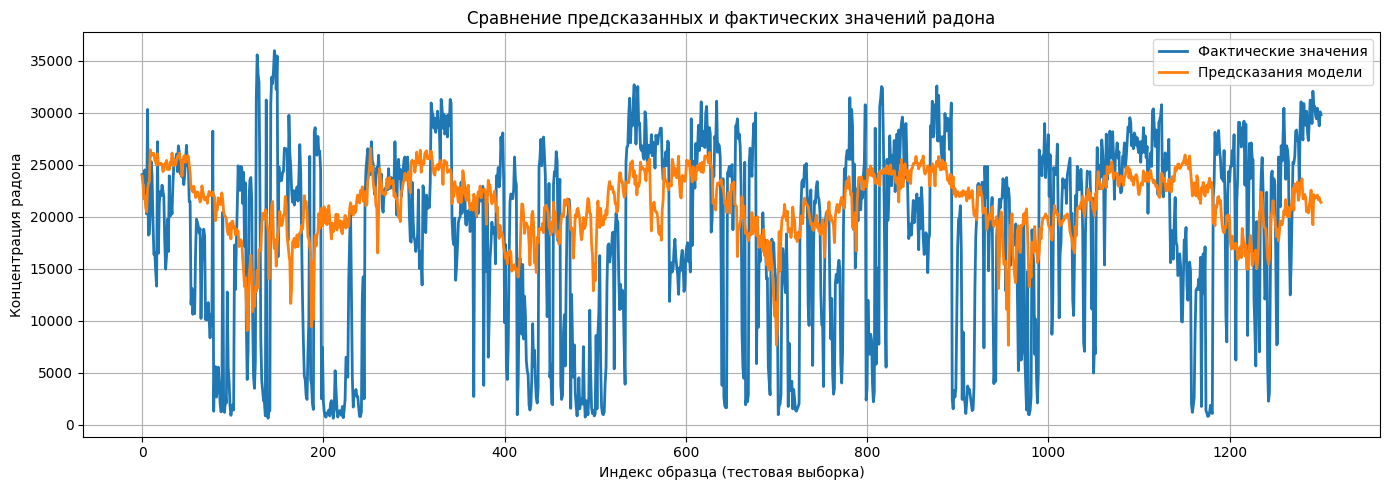

In [24]:
# Визуализация: фактические значения и предсказания
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Фактические значения', linewidth=2)
plt.plot(final_preds, label='Предсказания модели', linewidth=2)
plt.title('Сравнение предсказанных и фактических значений радона')
plt.xlabel('Индекс образца (тестовая выборка)')
plt.ylabel('Концентрация радона')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

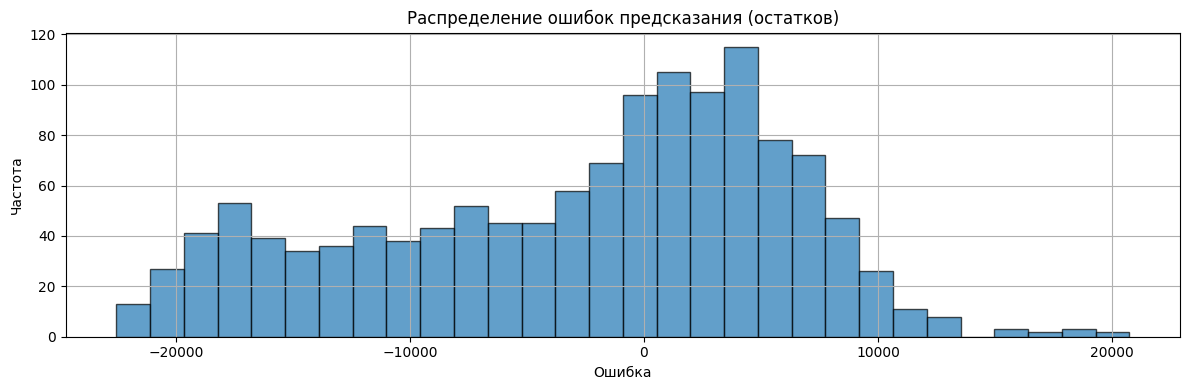

In [25]:
# Визуализация: остатки (ошибки прогноза)
residuals = y_test - final_preds
plt.figure(figsize=(12, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Распределение ошибок предсказания (остатков)')
plt.xlabel('Ошибка')
plt.ylabel('Частота')
plt.grid(True)
plt.tight_layout()
plt.show()